<a href="https://colab.research.google.com/github/sh1vam31/Complete_DataScience/blob/main/Linear_Regression_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Linear Regression**



Linear Regression is a method to find a relationship between input variables (features) and an output variable (target).

***Importing Basic Libraries***



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**How can we load it in Python using pandas and see the first few rows?**.

In [5]:
df = pd.read_csv("Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Exploring the Data

Check your dataset by some of the commands to quickly see its size, column names, missing values, and basic statistics.

In [9]:
print(df.shape)
print()
print(df.columns)
print()
print(df.isnull().sum())
print()
print(df.describe())

(1000, 9)

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000              970.000000   
mean    500.500000    10.059970             16.982000                4.579381   
std     288.819436     5.696656              7.204553                2.914394   
min       1.000000     0.590000              5.000000                0.000000   
25%     250.750000     5.105000             11.000000                2.000000   
50%     500.500000    10.1

### Handling Null Values
Fill the missing values in the categorical columns by replacing them with the most frequent value in each column (Mode).

In [14]:
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


Fill the missing values in the numerical columns by replacing them with the means or median , if the distribution is normal so we use the mean , if the distribution will be skwied then we will use the median .

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


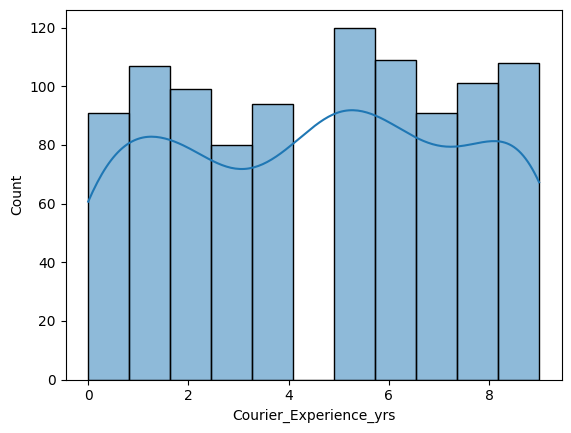

In [15]:
sns.histplot(df['Courier_Experience_yrs'], kde = True)  # the distribution is not normal so we use the median
median = df['Courier_Experience_yrs'].median()
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(median)

In [16]:
print(df.isnull().sum())

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


## Visualizing the Data
Visualize the relationships between all pairs of variables in the dataset to see patterns and correlations.

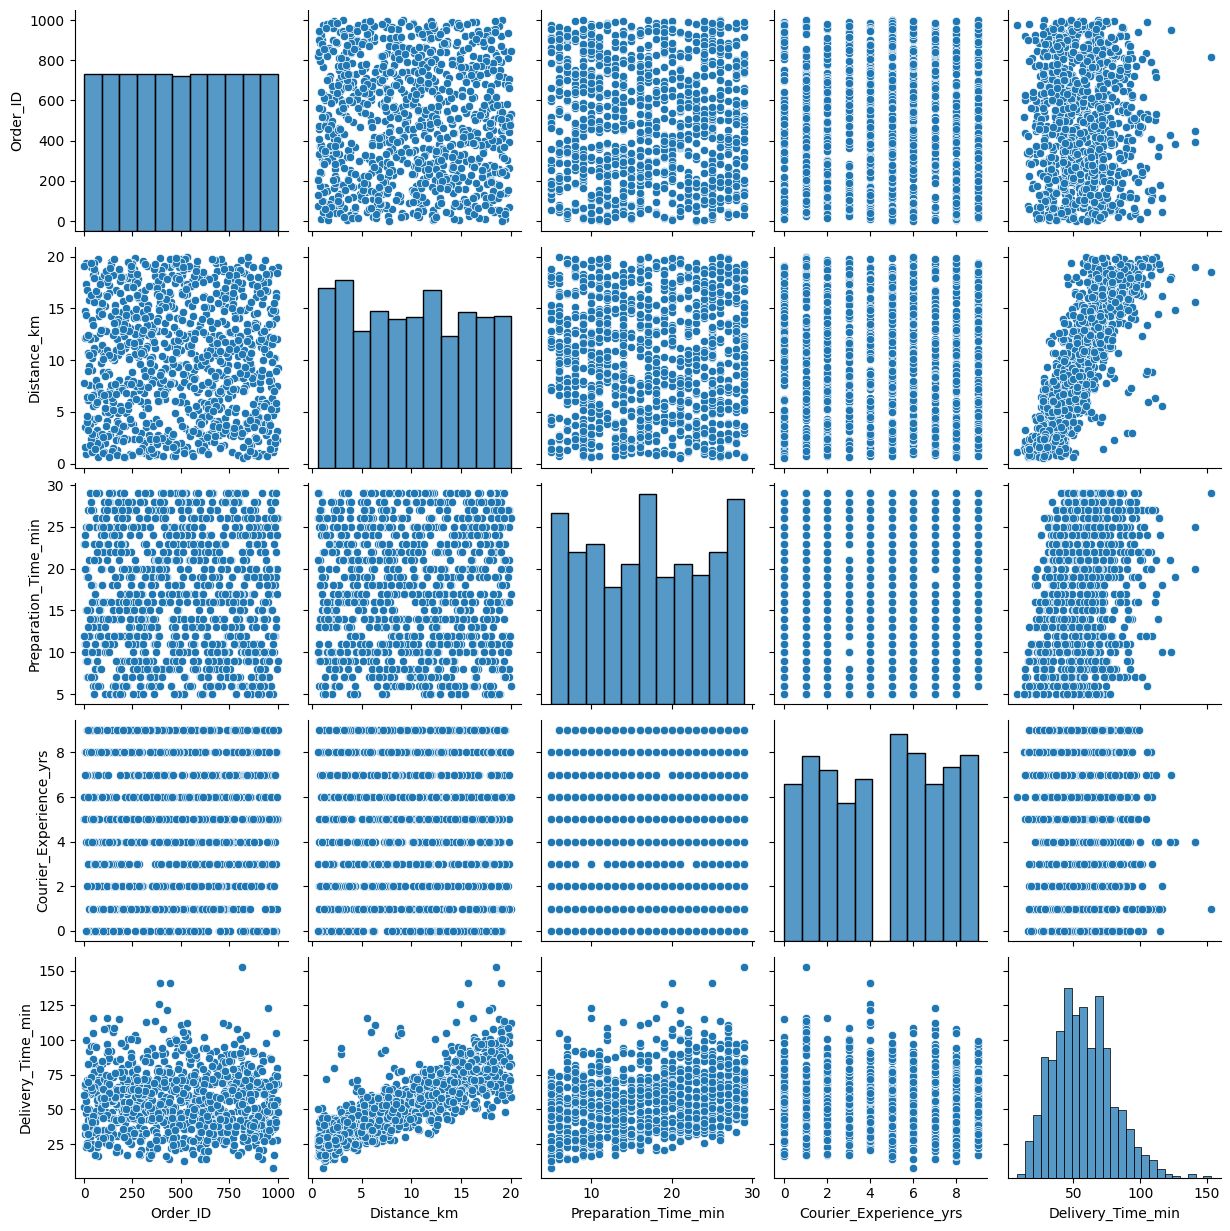

In [17]:
sns.pairplot(df)
plt.show()

### Mapping Values
Linear Regression works only on numeric data, so we need to convert categorical columns into numbers.

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Weather'] = le.fit_transform(df['Weather'])
df['Traffic_Level'] = le.fit_transform(df['Traffic_Level'])
df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])
df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,1,0,2,12,1.0,43
1,738,16.42,0,2,1,0,20,2.0,84
2,741,9.52,1,1,3,2,28,1.0,59
3,661,7.44,2,2,0,2,5,1.0,37
4,412,19.03,0,1,2,0,16,5.0,68


If i do Label Encoding so the linear regassion model may predict the Sunny > Rainy > Cloudy becouse in Label Encoding we get output like this
Weather:

1.   Cloudy → 0
2.   Rainy  → 1
3.   Sunny  → 2

so it may think -> Sunny is twice as much as Cloudy

So we use the Dummy variables
Dummy variables = converting categories into separate 0/1 columns.

In [20]:
cols = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']

In [21]:
df_dummies = pd.get_dummies(df, columns= cols)

In [22]:
df_dummies = df_dummies.astype(int)

In [29]:
df_dummies.head()


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_0,Weather_1,Weather_2,Weather_3,Weather_4,Traffic_Level_0,Traffic_Level_1,Traffic_Level_2,Time_of_Day_0,Time_of_Day_1,Time_of_Day_2,Time_of_Day_3,Vehicle_Type_0,Vehicle_Type_1,Vehicle_Type_2
0,522,7,12,1,43,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,738,16,20,2,84,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,741,9,28,1,59,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,661,7,5,1,37,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,412,19,16,5,68,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0


In [28]:
print(df_dummies.shape)

(1000, 20)
